# ESMF-like renormalization of weights

One current limitation of smmregrid is that NaN propagates through the computation. This implies that if you have a coordinate-changing NaN mask (typically occurring in ocean 3D data or in some time-varying observational reanalysis) we should compute a weight for each time frame. This is currently done with `mask_dim` which is mostly used for `depth` in oceanic data. Time varying data is currently not supported.

## The workaround

@garciampred opened a PR suggesting that it is possible to ESMF-like solution to deal with this. Indeed, ESMF uses a trick that we discussed back in the days, which implies estmating the amount of NaN in the data, removing the the weights where necessary, and renormalizating the final matrix. 

However, this is not enough. Given that smmregrid uses the first time step to compute the weights, it is important that if this option, called `skipna`, is active, the original data is modified so that that the weights is computed for the entire 2d time frame. This is an extra modification added to origianal @garciampred work added in this PR. 

Let's see how it works by loading a 3D ocean data. 

In [1]:
import numpy as np
import xarray as xr
from smmregrid import Regridder
import os
LOGLEVEL='WARNING'
INDIR = 'tests/data'
xfield = xr.open_dataset(os.path.join(INDIR, 'so3d-nemo.nc')).isel(time=0); var='so'; coord='lev'
#xfield = xr.open_dataset(os.path.join(INDIR, 'temp3d-fesom.nc')).isel(time=0); var='temp'; coord='nz1'
cfield = xr.open_dataset(os.path.join(INDIR, 'ua-ecearth.nc')).isel(time=0)

<frozen importlib._bootstrap>:491: RuntimeWarning: The global interpreter lock (GIL) has been enabled to load module 'cftime._cftime', which has not declared that it can run safely without the GIL. To override this behavior and keep the GIL disabled (at your own risk), run with PYTHON_GIL=0 or -Xgil=0.


You can inspect this file, but you will see that it has 18 vertical levels with increasing mask size as long as you go deep. 
Usual regridder will work smoothly, but it will compute one weight for each level. Precise but slow and not flexible, since it is based on the internal automatic detection of vertical dimension by `GridInspector`. You can see an output for the 10th level here below. Entire operation is 47seconds, but is fine since weights are computed once. 

/home/paolo/smmregrid/smmregrid/griddetector.py:126: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim_name, size in dimsdict.items():
<frozen _collections_abc>:883: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
/home/paolo/smmregrid/smmregrid/cdogenerate.py:104: UserWarning: Unlimited dimension(s) {'time'} declared in 'dataset.encoding', but not part of current dataset dimensions. Consider removing {'time'} from 'dataset.encoding'.
  grid.to_netcdf(grid_file.name)
/home/paolo/smmregrid/smmregrid/griddetector.py:126: FutureWarning: The return type of `Dataset.dims` will be changed to ret

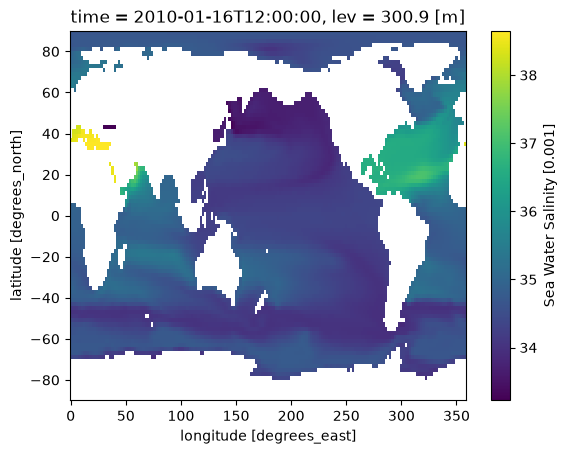

In [2]:
regrid_default = Regridder(xfield, 'r180x90', loglevel=LOGLEVEL)
default = regrid_default.regrid(xfield).isel({coord: 10})[var]
default.plot()

However, if we imagine to have the same data but with a vertical coordinate that is not the one expected by smmregrid, the approach will fail, and will compute only one weights that will be applied to everything and produce a mess propagating NaN (more precisely, propagating 1e20 which is the value for NaN in the tensordot operation).  AQUA developers know the pain pretty well. To do so we rename the vertical coordinate in something unpredictable.

/home/paolo/smmregrid/smmregrid/griddetector.py:126: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim_name, size in dimsdict.items():
<frozen _collections_abc>:883: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
/home/paolo/smmregrid/smmregrid/cdogenerate.py:104: UserWarning: Unlimited dimension(s) {'time'} declared in 'dataset.encoding', but not part of current dataset dimensions. Consider removing {'time'} from 'dataset.encoding'.
  grid.to_netcdf(grid_file.name)
/home/paolo/smmregrid/smmregrid/griddetector.py:126: FutureWarning: The return type of `Dataset.dims` will be changed to ret

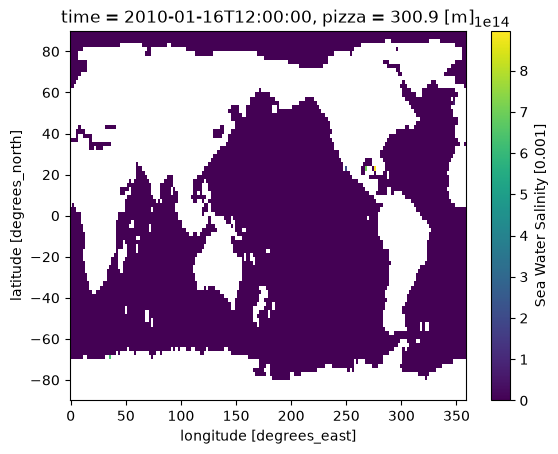

In [3]:
xfield_mod = xfield.rename({coord: 'pizza'})
regrid_broken = Regridder(xfield_mod, 'r180x90', loglevel=LOGLEVEL)
broken = regrid_broken.regrid(xfield_mod).isel(pizza=10)[var]
broken.plot()

And here comes the `skipna=True` option. With this feature we compute the weights once assuming there is no mask, and then we renormalize the weights accordingly to each level as a function of the original data at each computation. Weights computation is super fast (only one level), we still need to assess the performance loss in computing the regrid 

2026-07-16 15:24:49 | smmregrid.Regrid |  WARNING -> skipna is enabled with na_thres=0.5. This will affect the regridding behavior.
/home/paolo/smmregrid/smmregrid/griddetector.py:126: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim_name, size in dimsdict.items():
<frozen _collections_abc>:883: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
/home/paolo/smmregrid/smmregrid/griddetector.py:126: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimensi

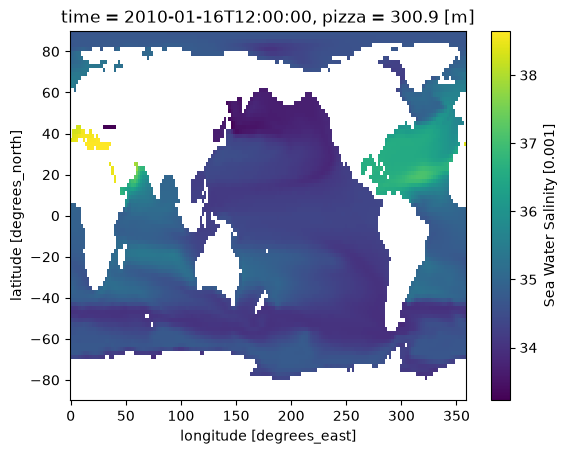

In [4]:
regrid_magic = Regridder(xfield_mod, 'r180x90', loglevel=LOGLEVEL, skipna=True, na_thres=0.5)
magic = regrid_magic.regrid(xfield_mod).isel(pizza=10)[var]
magic.plot()

We can then assess the difference from this and the default case, and it is just numerical error! So with `skipna=True` we can get almost identical results without knowing the vertical coordinate! 

/work/users/paolo/miniconda3/envs/smmregrid/lib/python3.14t/site-packages/sparse/numba_backend/_umath.py:529: RuntimeWarning: divide by zero encountered in divide
  fill_value_array = self.func(*zero_args, dtype=self.dtype, **self.kwargs)
/work/users/paolo/miniconda3/envs/smmregrid/lib/python3.14t/site-packages/sparse/numba_backend/_umath.py:529: RuntimeWarning: divide by zero encountered in divide
  fill_value_array = self.func(*zero_args, dtype=self.dtype, **self.kwargs)


max diff default vs magic 2.842170943040401e-14


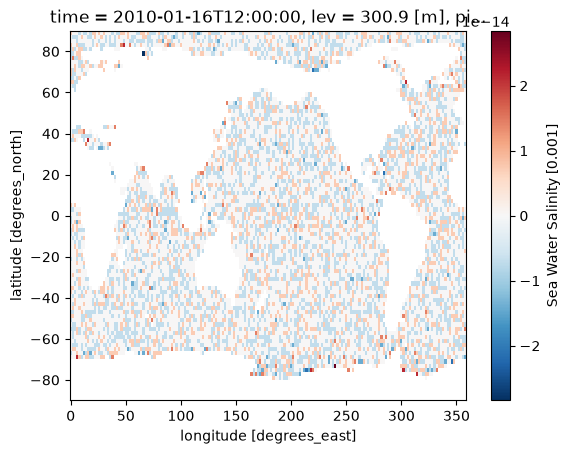

In [5]:
(default - magic).plot()
print('max diff default vs magic', np.max(np.abs(default - magic)).values)

## A bit of benchmark
Of course the overhead of renormalization is non-neglibile. However, as can be seen below, the `skipna` is actually faster. 

In [6]:
import timeit
import pandas as pd
NR = 50

one = timeit.timeit(lambda: regrid_default.regrid(xfield)[var].isel({coord: [2, 10, 17]}).values, number = NR)
two = timeit.timeit(lambda: regrid_magic.regrid(xfield_mod)[var].isel(pizza=[2, 10, 17]).values, number = NR)


/home/paolo/smmregrid/smmregrid/griddetector.py:126: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim_name, size in dimsdict.items():
<frozen _collections_abc>:883: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
2026-07-16 15:24:52 | smmregrid.Regrid |  WARNING -> Found scalar coordinates ['time']. If have selected a along a masked dimensions,regridding might fail. Please consider subsetting with [] or with slice
2026-07-16 15:24:52 | smmregrid.Regrid |  WARNING -> Found scalar coordinates ['time']. If have selected a along a masked dimensions,regridding might fail. Please consider subse

In [7]:

cnames = ['DefaultTime (s)', 'SkipnaTime (s)', 'Default', 'skipna']
df = pd.DataFrame([[one, two, one/one, two/one]], columns = cnames)
df

,DefaultTime (s),SkipnaTime (s),Default,skipna
0,19.306705,12.328111,1.0,0.63854


A case without mask to ensure that the problem is the mask computation

In [8]:
import timeit
import pandas as pd
NR = 20
regrid_default2 = Regridder(cfield, 'r180x90', loglevel=LOGLEVEL)
default = regrid_default2.regrid(cfield)
regrid_magic2 = Regridder(cfield, 'r180x90', loglevel=LOGLEVEL, skipna=True, na_thres=0.5)
magic = regrid_magic2.regrid(cfield)
one = timeit.timeit(lambda: regrid_default2.regrid(cfield)['ua'].values, number = NR)
two = timeit.timeit(lambda: regrid_magic2.regrid(cfield)['ua'].values, number = NR)
cnames = ['DefaultTime (s)', 'SkipnaTime (s)', 'Default', 'skipna']
df = pd.DataFrame([[one, two, one/one, two/one]], columns = cnames)
df

/home/paolo/smmregrid/smmregrid/griddetector.py:126: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim_name, size in dimsdict.items():
<frozen _collections_abc>:883: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
/home/paolo/smmregrid/smmregrid/cdogenerate.py:104: UserWarning: Unlimited dimension(s) {'time'} declared in 'dataset.encoding', but not part of current dataset dimensions. Consider removing {'time'} from 'dataset.encoding'.
  grid.to_netcdf(grid_file.name)
/home/paolo/smmregrid/smmregrid/griddetector.py:126: FutureWarning: The return type of `Dataset.dims` will be changed to ret

,DefaultTime (s),SkipnaTime (s),Default,skipna
0,3.877953,7.137251,1.0,1.840468


## Summary

There is still a lot to be done, but this `skipna` function seems promising. We need to evalute the role of the `na_thres` parameter, which controls the amount of NaN to be excluded. Apparently, with `na_thres=1` we can get the same outcome of CDO, but we can some coastal erosion so that I still need to investigate. Similarly, the procedure might be optimized, since we are getting a bit too much warnings. 

Surprisingly, the new implementation is 50% faster. The only option to explain this is that we do not use masked arrays. 

However, this is very promising since might allow a smooth usage of smmregrid on undefined or time-varying nan datasets, or some simpler condition where computing the level-weight is cumbersome. 

If you read up to this point, well, thanks you a lot!

### Code breakdown 
Deeper investigation by trying to benchmark the mask operation 

In [9]:
import xarray as xr
from smmregrid import Regridder
import os
LOGLEVEL='WARNING'
INDIR = 'tests/data'
regrid_default = Regridder(os.path.join(INDIR, 'so3d-nemo.nc'), 'r180x90', loglevel=LOGLEVEL)
xfield = xr.open_dataset(os.path.join(INDIR, 'so3d-nemo.nc'))


/home/paolo/smmregrid/smmregrid/griddetector.py:126: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim_name, size in dimsdict.items():
<frozen _collections_abc>:883: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.


In [10]:
import dask 
import numpy
LEV=10
horizontal_dims=['i', 'j']
weights = regrid_default.grids[0].weights.isel(lev=LEV)
source_data = xfield['so'].isel(lev=LEV)
weights_matrix = regrid_default.grids[0].weights_matrix[LEV-1]
source_array = source_data.data
kept_dims = [dim for dim in source_data.dims if dim not in horizontal_dims]
kept_shape = [source_data.sizes[dim] for dim in kept_dims]
if isinstance(source_array, dask.array.Array):
    source_array = dask.array.reshape(source_array, kept_shape + [-1])
else:
    source_array = numpy.reshape(source_array, kept_shape + [-1])


In [11]:
invalid = dask.array.isnan(source_array) | dask.array.isinf(source_array)
source_array = dask.array.where(invalid, 1e20, source_array)
dst_grid_mask = weights.dst_grid_imask
target_dask = dask.array.tensordot(source_array, weights_matrix, axes=1)

# define and compute the new mask (alternative to skipna)
    # broadcast the mask on all the remaining dimensions and apply it with where
    # Reshape mask to broadcastable shape (avoid intermediate boolean array creation)
mask_shape = [1 for d in kept_shape] + [-1]
target_mask = dst_grid_mask.data.reshape(mask_shape).astype(bool)
target_dask = dask.array.where(target_mask, target_dask, numpy.nan)

In [12]:
non_nan_mask = dask.array.notnull(source_array)
source_array_zero_filled = dask.array.where(non_nan_mask, source_array, 0.0)
numerator = dask.array.tensordot(source_array_zero_filled, weights_matrix, axes=1)
denominator = dask.array.tensordot(non_nan_mask.astype(weights_matrix.dtype), weights_matrix, axes=1)

# Avoid division by zero
target_dask = dask.array.where(denominator > 0, numerator / denominator, numpy.nan)

# na_thres logic, safety check in init
total_weights = weights_matrix.sum(axis=0)
# safety check on total weights to avoid division by zero
safe_total_weights = dask.array.where(total_weights > 0, total_weights, 1.0)
missing_fraction = 1.0 - (denominator / safe_total_weights)
# clip missing_fraction to [0, 1] to avoid numerical issues
missing_fraction = dask.array.clip(missing_fraction, 0.0, 1.0)
target_dask = dask.array.where(missing_fraction > 1.0, numpy.nan, target_dask)